In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
manyscan=1 # want to plot ~10 scans around the good-seeing scan
line=0 # this is just an index for Ca II H. In the .py file I used for the clustering, this is 1 if H-beta.  Don't worry about this key...
n_clusters0=35 # number of clusters
colors = plt.cm.turbo(np.linspace(0,1,n_clusters0)) #colormap for plotting

# define indices bounding the lines we could cluster
hbeta_low =353
hbeta_high = 640
caII_low = 480 #570 for first calibration pre March 6
caII_high = 690
hepsilon_low = 685
hepsilon_high = 810

#cutoff0 = 1.5 # for more than one frame
if line == 1:
    cutoff0=9 # for h-beta
    if manyscan:
        cutoff0=5 
if line == 0: # for ca II
    cutoff0=2.5
    if manyscan:
        cutoff0=2.5 

# number of clusters
if line == 1:
    n_clusters0 = 35 # 10 works for hbeta, 6 for Ca II H seems to be all that's needed, 6 also for h-ep
if line == 0:
    n_clusters0 = 35

#spatial limits (along slit) of ribbon -different for arms 1 and 2
if line == 1:
    startspace = 300 
    endspace = 1800 
if line == 0:
    startspace = 300 
    endspace = 1700
    
# define rest wavelengths
if line == 1:
    cent= 486.1375
if line == 0:
    cent = 396.85
    
# define limits of line; essentially the blue and red bounds of spectral range to cluster
if line == 1:
    linelow = hbeta_low
    linehigh = hbeta_high
if line == 0:
    linelow = caII_low
    linehigh = caII_high

# function to convert observed wavelength to velocity
def find_velocity(rest_wl,obs_wl):
    c= 299792458 # m/s
    
    return c*(obs_wl-rest_wl)/(obs_wl)

base = '/Users/coletamburri/Desktop/11Aug2024_kmeans_result_21May2026/' # change to directory you need

In [4]:
#load clustering file
km_file = np.load(base+'CaIIH_clustering_result.npz',allow_pickle='True')

In [7]:
#extract variables from clustering file
xarr_ch=km_file['xarr_ch'] # x coordinates for pcolormesh
yarr_ch=km_file['yarr_ch'] # y coordinates for pcolormesh
frame_line=km_file['frame_line'] # scans of interest, with along-slit direction limited just to what we want to see
normprofiles_line=km_file['normprofiles_line'] # normalized spectral line profiles
times=km_file['times'] # times for each ViSP slit position
km01=km_file['km0'] # numpy array containing the KMeansClusterer object (nltk)
groups0=km_file['labels0'] # numpy array containing the cluster number for each pixel
#arr_normprofs0=km_file['arr_normprofs0'] # 2D array (pixel number x wavelength) containing the normalized line profile for each pixel
wave=km_file['wave'] # wavelength array for chosen arm
sortedinds=km_file['sortedinds'] # cluster indices sorted by weighted mean (blueshifted to redshifted
selwls=km_file['selwls'] # wavelength array for chosen line only
sortedwls=km_file['sortedwls'] # location of calculated line center (0 is the first index in "selwls")

#read pandas dataframe containing clusters from csv
# contains the mask info, including the x values, y values, and cluster number corresponding to each pixel
df_mask = pd.read_csv('/Users/coletamburri/Desktop/11Aug2024_kmeans_result_21May2026/CaIIH_df.csv') 

#the result of kmeans is a weird class from the nltk package; extract the necessary info with this line
km0 = km01.item()   # extract the object so we can read variables directly as attributes of the class

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_9476/2290992944.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


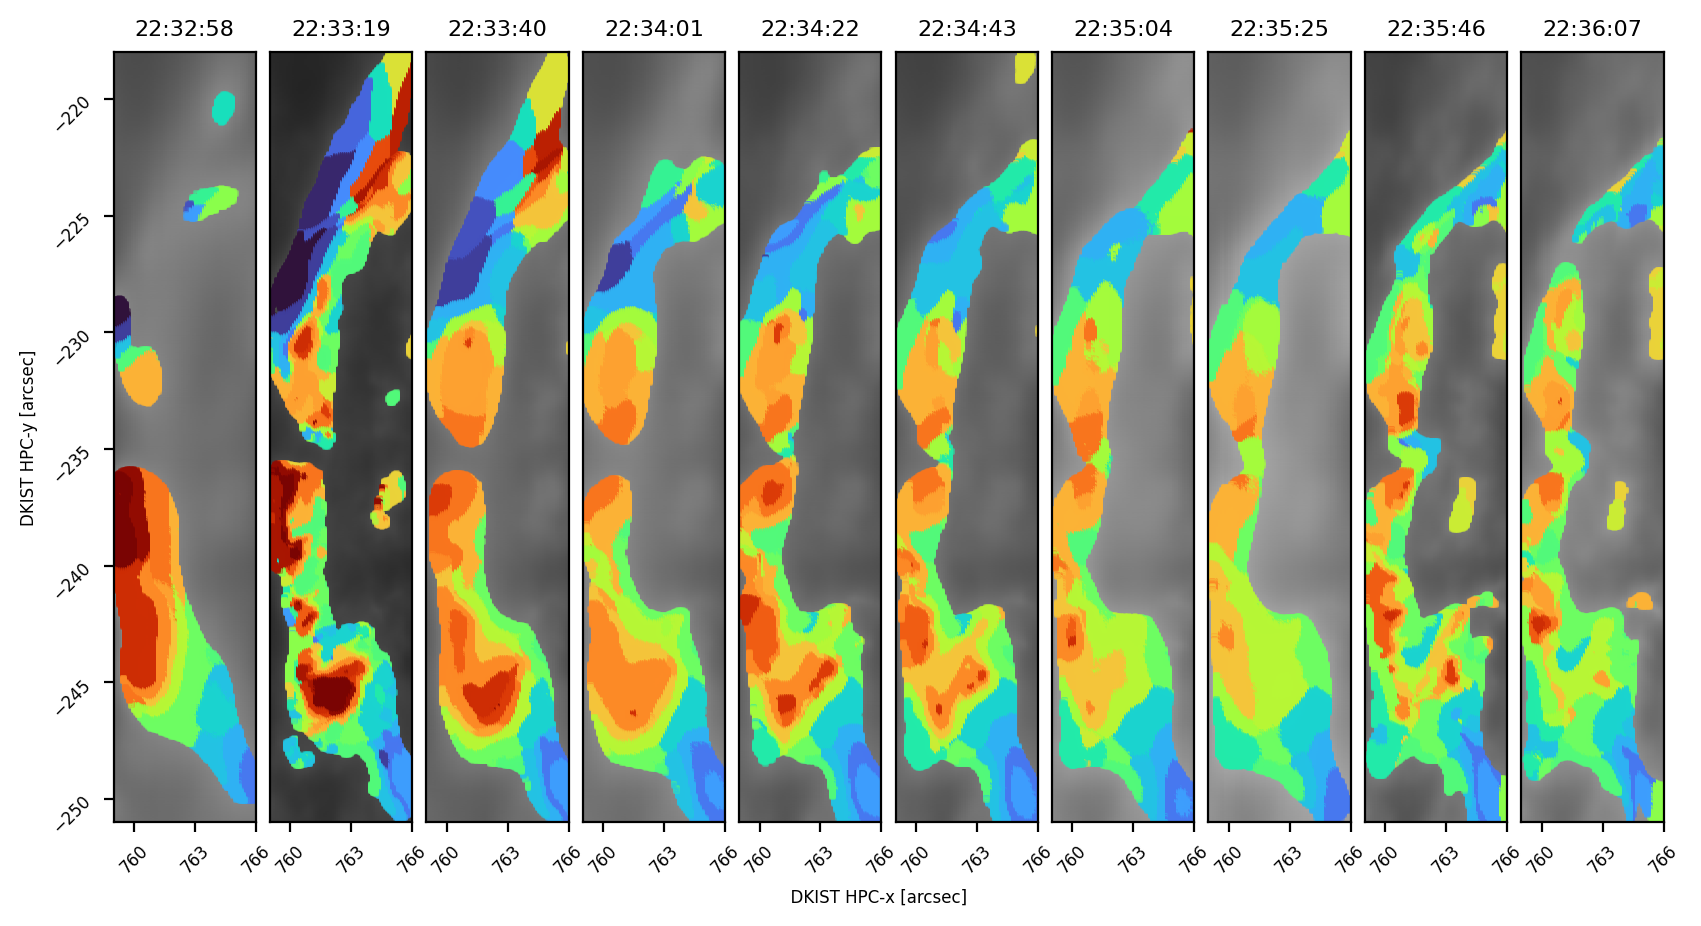

In [8]:
# plotting the scans with color-coded pixels based on which cluster the pixel corresponds to

if manyscan ==1:
    fig,ax=plt.subplots(1,10,figsize=(10,5),dpi=200)

    for i in range(10):
        ax.flatten()[i].pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[(91*i):(91*(i+1)),:]),cmap='grey',alpha=1)
        lower_threshold=(91*i)
        upper_threshold=(91*(i+1))
        sel = df_mask[(df_mask['x'] > lower_threshold) & (df_mask['x'] < upper_threshold)]
        xmask_sel = sel['x'].values-lower_threshold
        ymask_sel = sel['y'].values
        distlocs_sel = sel['dist'].values

        ax.flatten()[i].scatter(xarr_ch[xmask_sel],yarr_ch[ymask_sel],2,color=colors[distlocs_sel],alpha=.6,marker='s')
        ax.flatten()[i].invert_xaxis()
        ax.flatten()[i].invert_yaxis()
        ax.flatten()[i].set_ylim([-251,-218])
        ax.flatten()[i].set_xlim([759,766])
        ax.flatten()[i].tick_params(axis='x', labelrotation=45)
        ax.flatten()[i].tick_params(axis='y', labelrotation=45)
        if i>0:
            ax.flatten()[i].set_yticks([])
        
        ax.flatten()[i].tick_params(axis='x',labelsize=6)
        ax.flatten()[i].tick_params(axis='y',labelsize=6)
        ax.flatten()[i].set_title(times[57+91*i][11:19],fontsize=8)
        ax.flatten()[i].set_xticks([760,763,766])
    ax.flatten()[0].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)
    ax.flatten()[4].set_xlabel('                          DKIST HPC-x [arcsec]',fontsize=6) # just wanted to see if I could add the spaces manually teehee
else:
    fig,ax=plt.subplots(figsize=(1.5,4),dpi=200)

    ax.pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[:,:]),cmap='grey',alpha=1)
    ax.scatter(xarr_ch[x_mask0],yarr_ch[y_mask0],1.2,color=colors[distlocs],alpha=.6,marker='s')
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_ylim([-251,-218])
    ax.set_xlim([759,766])
    ax.tick_params(axis='y', labelrotation=90)
    ax.set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)
    ax.set_xlabel('DKIST HPC-x [arcsec]',fontsize=6)
    ax.tick_params(axis='x',labelsize=6)
    ax.tick_params(axis='y',labelsize=6)

fig.subplots_adjust(wspace=0.1)


fig.show()


/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_83014/1198615281.py:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


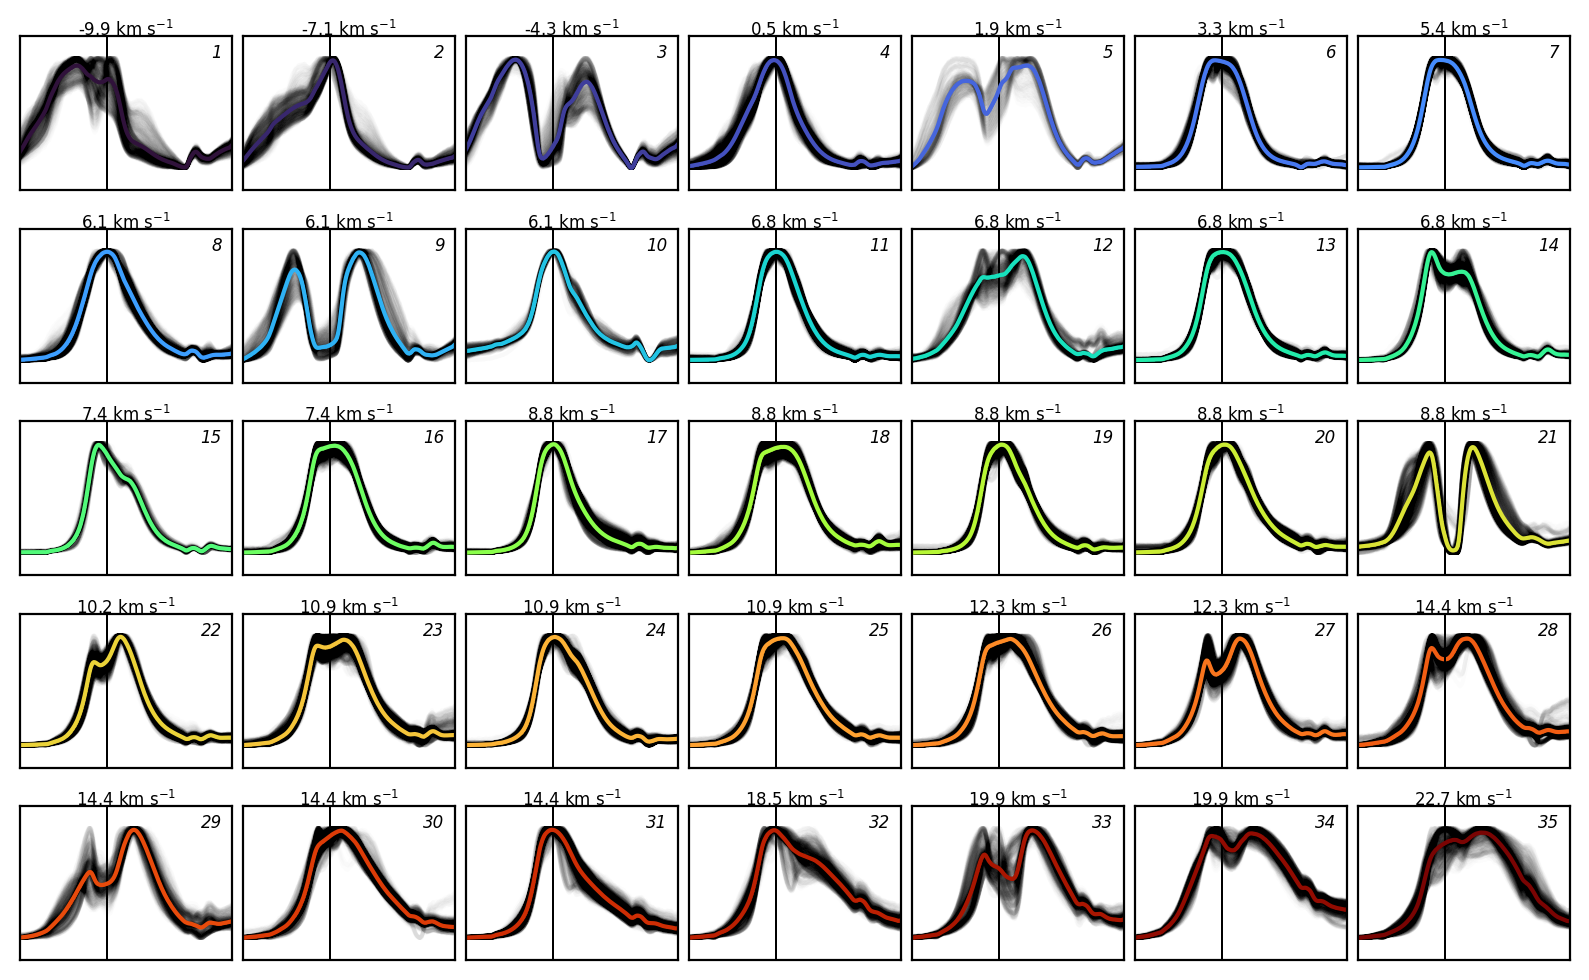

In [9]:

#fig,ax=plt.subplots(3,4,figsize=(5,4),dpi=200)
#fig,ax=plt.subplots(2,3,figsize=(5,4),dpi=200) #if hep
fig,ax=plt.subplots(5,7,figsize=(10,6),dpi=200) #if hep and caii
arr_normprofs0 = normprofiles_line

    
for i in range(len(arr_normprofs0)):
    curve = arr_normprofs0[i]
    group = groups0[i]
    ind = np.where(sortedinds==group)[0][0]
    if km0.means()[group][0] < km0.means()[group][int(len(km0.means()[group])/2)]:
        ax.flatten()[ind].plot(wave[linelow:linehigh],curve,alpha=0.01,color='black')
        ax.flatten()[ind].axvline(cent,linewidth=0.6,c='black')
    else:
        ax.flatten()[ind].plot(wave[linelow:linehigh],curve,alpha=0.005,color='black')
        ax.flatten()[ind].axvline(cent,linewidth=0.6,c='black')   

    

for i in range(n_clusters0):
    if line == 1:
        if km0.means()[sortedinds[i]][0] < km0.means()[sortedinds[i]][int(len(km0.means()[sortedinds[i]])/2)]:
            ax.flatten()[i].plot(wave[linelow:linehigh],km0.means()[sortedinds[i]],marker='*',color=colors[i],markersize=.1)
            ax.flatten()[group].axvline(cent,linewidth=0.6,c='black')
            ax.flatten()[i].tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False)
            ax.flatten()[i].tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            left=False,      # ticks along the bottom edge are off
            right=False,         # ticks along the top edge are off
            labelleft=False)# labels along the bottom edge are off
            ax.flatten()[i].text(0.95, 0.95, str(i+1), transform=ax.flatten()[i].transAxes, \
                 ha='right', va='top', fontsize=6, fontstyle='italic')
            ax.flatten()[i].set_ylim([-0.2,1.2])
            ax.flatten()[i].set_xlim([wave[linelow],wave[linehigh]])
            
            obs_wl = selwls[int(sortedwls[i])]
            
            velocity = find_velocity(cent,obs_wl)
            ax.flatten()[i].set_title(str(round(velocity/1e3,1))+r' km s$^{-1}$',fontsize=6,y=.895)
        else:
            ax.flatten()[i].plot(wave[linelow:linehigh],km0.means()[sortedinds[i]],marker='*',color='grey',markersize=.1,alpha=0.5)
            ax.flatten()[group].axvline(cent,linewidth=0.6,c='black',alpha=0.2)
            ax.flatten()[i].tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False)
            ax.flatten()[i].tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            left=False,      # ticks along the bottom edge are off
            right=False,         # ticks along the top edge are off
            labelleft=False)# labels along the bottom edge are off
            ax.flatten()[i].text(0.95, 0.95, str(i+1), transform=ax.flatten()[i].transAxes, \
                 ha='right', va='top', fontsize=6, fontstyle='italic',alpha=0.5)
            ax.flatten()[i].set_ylim([-0.2,1.2])
            ax.flatten()[i].set_xlim([wave[linelow],wave[linehigh]])
    else:
        ax.flatten()[i].plot(wave[linelow:linehigh],km0.means()[sortedinds[i]],marker='*',color=colors[i],markersize=.1)
        ax.flatten()[group].axvline(cent,linewidth=0.6,c='black')
        ax.flatten()[i].tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False)
        ax.flatten()[i].tick_params(
        axis='y',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        left=False,      # ticks along the bottom edge are off
        right=False,         # ticks along the top edge are off
        labelleft=False)# labels along the bottom edge are off
        ax.flatten()[i].text(0.95, 0.95, str(i+1), transform=ax.flatten()[i].transAxes, \
             ha='right', va='top', fontsize=6, fontstyle='italic')
        ax.flatten()[i].set_ylim([-0.2,1.2])
        ax.flatten()[i].set_xlim([wave[linelow],wave[linehigh]])
        
        obs_wl = selwls[int(sortedwls[i])]
        
        velocity = find_velocity(cent,obs_wl)
        ax.flatten()[i].set_title(str(round(velocity/1e3,1))+r' km s$^{-1}$',fontsize=6,y=.895)
        

fig.subplots_adjust(hspace=0.25,wspace=0.05)

fig.show()

